In [36]:
import os, re, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
import joblib
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

In [8]:
df = pd.read_csv("fake reviews dataset.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Shape: (40432, 4)
Columns: ['category', 'rating', 'label', 'text_']


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [9]:
# Exact columns in the supplied dataset
TEXT_COL = "text_"
LABEL_COL = "label"
RATING_COL = "rating"
TITLE_COL = None
CATEGORY_COL = "category"

print("TEXT:", TEXT_COL)
print("LABEL:", LABEL_COL)
print("RATING:", RATING_COL)
print("CATEGORY:", CATEGORY_COL)

TEXT: text_
LABEL: label
RATING: rating
CATEGORY: category


In [10]:
df = df.copy()

df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.upper()
df[CATEGORY_COL] = df[CATEGORY_COL].astype(str)
df[RATING_COL] = pd.to_numeric(df[RATING_COL], errors="coerce")

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print("Removed duplicate rows:", before - len(df))
print("Final shape:", df.shape)
print("\nLabels:")
print(df[LABEL_COL].value_counts())


Removed duplicate rows: 12
Final shape: (40420, 4)

Labels:
label
OR    20215
CG    20205
Name: count, dtype: int64


In [11]:
label_map = {"OR": 0, "CG": 1}

unknown = set(df[LABEL_COL].unique()) - set(label_map)

if unknown:
    raise ValueError(f"Unexpected labels found: {unknown}")

df["target"] = df[LABEL_COL].map(label_map).astype(int)

print("Label mapping:", label_map)
print("\nClass counts:")
print(df["target"].value_counts())
print("\nClass proportions:")
print(df["target"].value_counts(normalize=True).round(4))


Label mapping: {'OR': 0, 'CG': 1}

Class counts:
target
0    20215
1    20205
Name: count, dtype: int64

Class proportions:
target
0    0.5001
1    0.4999
Name: proportion, dtype: float64


In [12]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass proportions:")
print(df["target"].value_counts(normalize=True).round(4))

print("\nCategory count:", df[CATEGORY_COL].nunique())
print(df[CATEGORY_COL].value_counts())

print("\nRating distribution:")
print(df[RATING_COL].value_counts().sort_index())


Shape: (40420, 5)

Missing values:
category    0
rating      0
label       0
text_       0
target      0
dtype: int64

Duplicate rows: 0

Class proportions:
target
0    0.5001
1    0.4999
Name: proportion, dtype: float64

Category count: 10
category
Kindle_Store_5                  4728
Books_5                         4369
Pet_Supplies_5                  4251
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3944
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3847
Toys_and_Games_5                3792
Movies_and_TV_5                 3587
Name: count, dtype: int64

Rating distribution:
rating
1.0     2155
2.0     1967
3.0     3786
4.0     7965
5.0    24547
Name: count, dtype: int64


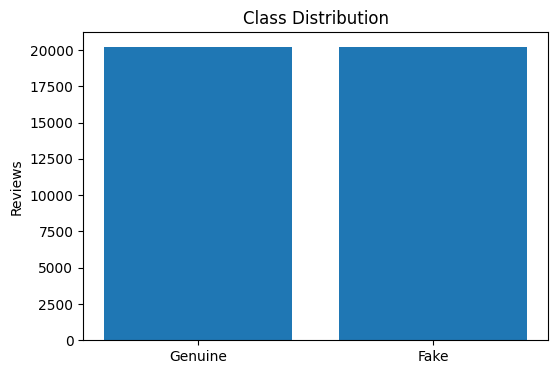

In [13]:
counts=df.target.value_counts().reindex([0,1],fill_value=0)
plt.figure(figsize=(6,4)); plt.bar(["Genuine","Fake"],counts); plt.ylabel("Reviews"); plt.title("Class Distribution"); plt.show()

In [14]:
def engineer_features(data, text_col, rating_col=None):
    out = data.copy()
    t = out[text_col].fillna("").astype(str)

    out["char_count"] = t.str.len()
    out["word_count"] = t.str.split().str.len()
    out["sentence_count"] = t.str.count(r"[.!?]+").clip(lower=1)
    out["avg_word_length"] = (
        out["char_count"] / out["word_count"].replace(0, np.nan)
    ).fillna(0)

    out["exclamation_count"] = t.str.count("!")
    out["question_count"] = t.str.count(r"\?")
    out["uppercase_count"] = t.str.count(r"[A-Z]")
    out["digit_count"] = t.str.count(r"\d")
    out["url_count"] = t.str.count(r"https?://|www\.")
    out["repeated_punctuation"] = t.str.count(r"[!?]{2,}")

    out["uppercase_ratio"] = (
        out["uppercase_count"] / out["char_count"].replace(0, np.nan)
    ).fillna(0)

    out["digit_ratio"] = (
        out["digit_count"] / out["char_count"].replace(0, np.nan)
    ).fillna(0)

    out["all_caps_words"] = t.apply(
        lambda x: sum(1 for w in x.split() if len(w) > 2 and w.isupper())
    )

    if rating_col in out.columns:
        out["rating_numeric"] = pd.to_numeric(out[rating_col], errors="coerce")

    return out

df = engineer_features(df, TEXT_COL, RATING_COL)

meta_preview = [
    "rating_numeric", "char_count", "word_count", "sentence_count",
    "avg_word_length", "exclamation_count", "question_count",
    "uppercase_ratio", "digit_ratio", "url_count",
    "repeated_punctuation"
]

display(df[meta_preview].describe().T)


,count,mean,std,min,25%,50%,75%,max
rating_numeric,40420.0,4.256358,1.144452,1.000000,4.000000,5.000000,5.000000,5.000000
char_count,40420.0,351.321227,369.850284,24.000000,107.000000,198.000000,439.000000,2827.000000
word_count,40420.0,67.474592,69.588164,1.000000,21.000000,39.000000,85.000000,373.000000
sentence_count,40420.0,5.312073,5.348813,1.000000,2.000000,3.000000,7.000000,133.000000
avg_word_length,40420.0,5.198249,0.722946,3.588235,4.851852,5.125628,5.451389,48.000000
exclamation_count,40420.0,0.397625,1.393855,0.000000,0.000000,0.000000,0.000000,133.000000
question_count,40420.0,0.052994,0.373101,0.000000,0.000000,0.000000,0.000000,18.000000
uppercase_ratio,40420.0,0.030719,0.047675,0.000000,0.018868,0.024561,0.032909,0.837398
digit_ratio,40420.0,0.002904,0.008387,0.000000,0.000000,0.000000,0.001682,0.331190
url_count,40420.0,0.005740,0.121703,0.000000,0.000000,0.000000,0.000000,6.000000


In [ ]:
plt.figure(figsize=(9, 5))

for label, name in [(0, "OR"), (1, "CG")]:
    values = df.loc[df.target == label, "word_count"]
    plt.hist(values, bins=50, alpha=.6, label=name)

plt.xlabel("Words per review")
plt.ylabel("Frequency")
plt.title("Review Length by Class")
plt.legend()
plt.show()

print("\nAverage word count by class:")
display(df.groupby("label")["word_count"].agg(["mean", "median", "std"]).round(2))


In [15]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " URL ", text)
    text = re.sub(r"[^a-z0-9!?\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean_review"] = df[TEXT_COL].apply(clean_text)

X = df["clean_review"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


Training samples: 32336
Testing samples : 8084


## TF-IDF representation


In [16]:
vectorizer=TfidfVectorizer(sublinear_tf=True,min_df=2,max_df=.95,ngram_range=(1,2),max_features=100000,strip_accents="unicode")
X_train_tfidf=vectorizer.fit_transform(X_train); X_test_tfidf=vectorizer.transform(X_test)
print("TF-IDF shape:",X_train_tfidf.shape)

TF-IDF shape: (32336, 100000)


## Model 1 — Logistic Regression

In [17]:
lr=LogisticRegression(max_iter=2000,class_weight="balanced",random_state=RANDOM_STATE)
lr.fit(X_train_tfidf,y_train); lr_pred=lr.predict(X_test_tfidf); lr_prob=lr.predict_proba(X_test_tfidf)[:,1]
print(classification_report(y_test,lr_pred,target_names=["OR","CG"]))

              precision    recall  f1-score   support

          OR       0.92      0.95      0.94      4043
          CG       0.95      0.92      0.94      4041

    accuracy                           0.94      8084
   macro avg       0.94      0.94      0.94      8084
weighted avg       0.94      0.94      0.94      8084



## 8. Multinomial Naive Bayes

In [18]:
nb=MultinomialNB(alpha=.5)
nb.fit(X_train_tfidf,y_train); nb_pred=nb.predict(X_test_tfidf); nb_prob=nb.predict_proba(X_test_tfidf)[:,1]
print(classification_report(y_test,nb_pred,target_names=["OR","CG"]))

              precision    recall  f1-score   support

          OR       0.95      0.86      0.90      4043
          CG       0.87      0.95      0.91      4041

    accuracy                           0.91      8084
   macro avg       0.91      0.91      0.91      8084
weighted avg       0.91      0.91      0.91      8084



## Model 3 — Linear SVM

In [19]:
svm=LinearSVC(C=1.0,class_weight="balanced",random_state=RANDOM_STATE)
svm.fit(X_train_tfidf,y_train); svm_pred=svm.predict(X_test_tfidf); svm_score=svm.decision_function(X_test_tfidf)
svm_prob=1/(1+np.exp(-np.clip(svm_score,-50,50)))
print(classification_report(y_test,svm_pred,target_names=["OR","CG"]))

              precision    recall  f1-score   support

          OR       0.95      0.96      0.95      4043
          CG       0.96      0.95      0.95      4041

    accuracy                           0.95      8084
   macro avg       0.95      0.95      0.95      8084
weighted avg       0.95      0.95      0.95      8084



## Model 4 — Random Forest on behavioral features

In [20]:
# Metadata / behavioral model

numeric_features = [
    "char_count", "word_count", "avg_word_length", "sentence_count",
    "exclamation_count", "question_count", "uppercase_count",
    "digit_count", "uppercase_ratio", "digit_ratio", "url_count",
    "repeated_punctuation", "all_caps_words", "rating_numeric"
]

X_meta = df[numeric_features].replace([np.inf, -np.inf], np.nan)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_meta, y,
    test_size=.20,
    random_state=RANDOM_STATE,
    stratify=y
)

rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf.fit(Xm_train, ym_train)
rf_pred = rf.predict(Xm_test)
rf_prob = rf.predict_proba(Xm_test)[:, 1]

print(classification_report(
    ym_test, rf_pred, target_names=["OR", "CG"]
))


              precision    recall  f1-score   support

          OR       0.77      0.76      0.77      4043
          CG       0.77      0.78      0.77      4041

    accuracy                           0.77      8084
   macro avg       0.77      0.77      0.77      8084
weighted avg       0.77      0.77      0.77      8084



## Model 5 — XGBoost

In [21]:
xgb=None; xgb_pred=xgb_prob=None
try:
    from xgboost import XGBClassifier
    xgb=Pipeline([("imputer",SimpleImputer(strategy="median")),("model",XGBClassifier(n_estimators=300,max_depth=6,learning_rate=.08,subsample=.85,colsample_bytree=.85,eval_metric="logloss",random_state=RANDOM_STATE,n_jobs=-1))])
    xgb.fit(Xm_train,ym_train); xgb_pred=xgb.predict(Xm_test); xgb_prob=xgb.predict_proba(Xm_test)[:,1]
    print(classification_report(ym_test,xgb_pred,target_names=["OR","CG"]))
except ImportError:
    print("XGBoost not installed. Optional: pip install xgboost")

              precision    recall  f1-score   support

          OR       0.79      0.76      0.78      4043
          CG       0.77      0.80      0.78      4041

    accuracy                           0.78      8084
   macro avg       0.78      0.78      0.78      8084
weighted avg       0.78      0.78      0.78      8084



In [22]:
def metrics(name, yt, pred, prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(yt, pred),
        "Precision": precision_score(yt, pred, zero_division=0),
        "Recall": recall_score(yt, pred, zero_division=0),
        "F1": f1_score(yt, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yt, prob)
    }

results = [
    metrics("TF-IDF + Logistic Regression", y_test, lr_pred, lr_prob),
    metrics("TF-IDF + Naive Bayes", y_test, nb_pred, nb_prob),
    metrics("Word TF-IDF + Linear SVM", y_test, svm_pred, svm_prob),
    metrics("Random Forest + Review Features", ym_test, rf_pred, rf_prob)
]

if xgb is not None:
    results.append(metrics("XGBoost + Review Features", ym_test, xgb_pred, xgb_prob))

results_df = (
    pd.DataFrame(results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Word TF-IDF + Linear SVM,0.9515,0.9574,0.9451,0.9512,0.9892
1,TF-IDF + Logistic Regression,0.9367,0.9514,0.9203,0.9356,0.9825
2,TF-IDF + Naive Bayes,0.9070,0.8745,0.9503,0.9108,0.9766
3,XGBoost + Review Features,0.7794,0.7701,0.7966,0.7831,0.8619
4,Random Forest + Review Features,0.7700,0.7666,0.7763,0.7714,0.8482


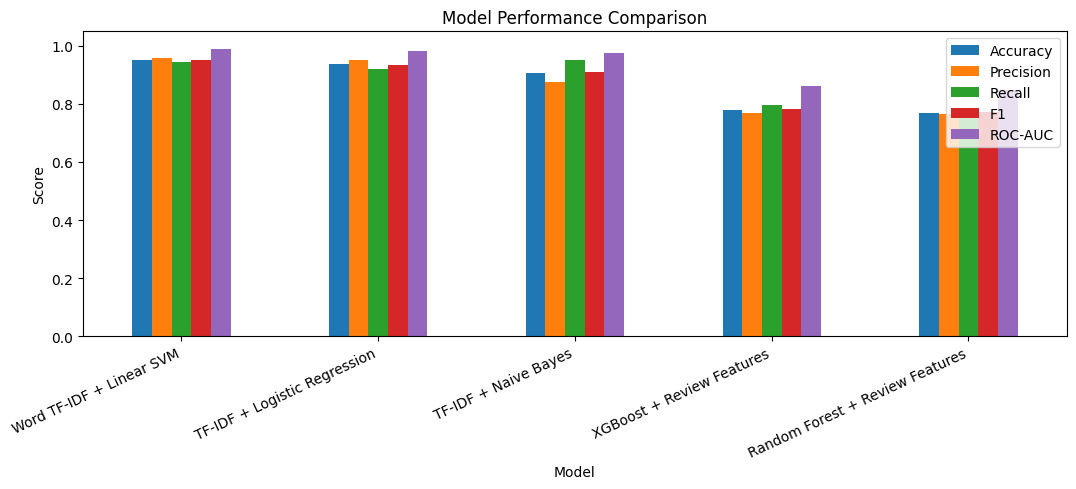

In [23]:
ax=results_df.set_index("Model")[["Accuracy","Precision","Recall","F1","ROC-AUC"]].plot(kind="bar",figsize=(11,5))
ax.set_ylim(0,1.05); ax.set_ylabel("Score"); ax.set_title("Model Performance Comparison"); plt.xticks(rotation=25,ha="right"); plt.tight_layout(); plt.show()

Best text model: Word TF-IDF + Linear SVM


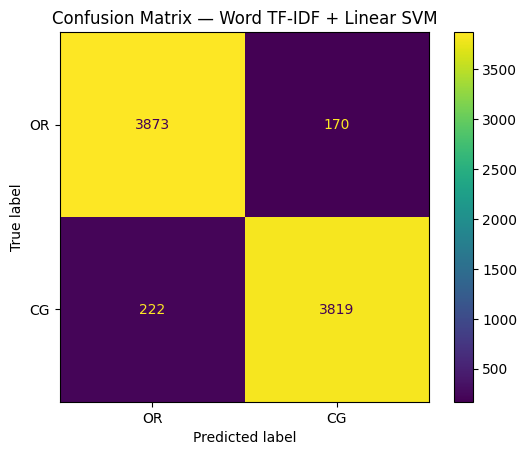

In [33]:
best_text = results_df[
    results_df["Model"].isin([
        "TF-IDF + Logistic Regression",
        "TF-IDF + Naive Bayes",
        "Word TF-IDF + Linear SVM"
    ])
].iloc[0]["Model"]

text_models = {
    "TF-IDF + Logistic Regression": (lr_pred, lr_prob),
    "TF-IDF + Naive Bayes": (nb_pred, nb_prob),
    "Word TF-IDF + Linear SVM": (svm_pred, svm_prob)
}

best_pred, best_prob = text_models[best_text]

print("Best text model:", best_text)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["OR", "CG"]
)

plt.title(f"Confusion Matrix — {best_text}")
plt.show()

<Figure size 800x600 with 0 Axes>

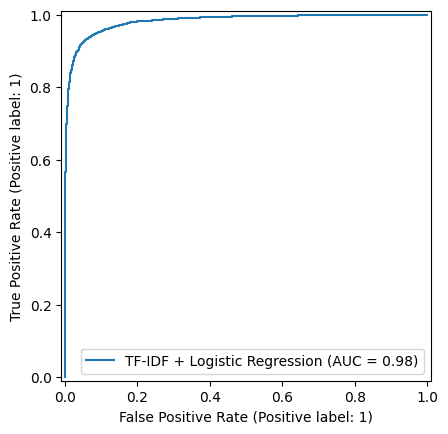

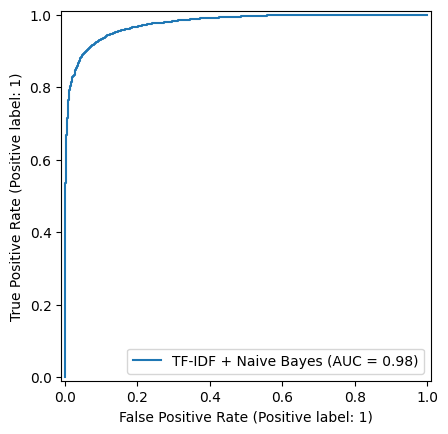

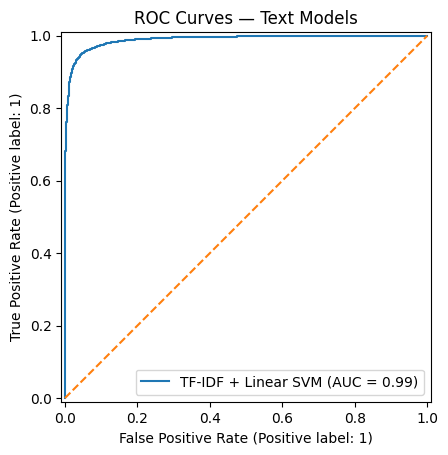

In [26]:
plt.figure(figsize=(8,6))
for name,(pred,prob) in text_models.items(): RocCurveDisplay.from_predictions(y_test,prob,name=name)
plt.plot([0,1],[0,1],"--"); plt.title("ROC Curves — Text Models"); plt.show()

In [27]:
tune_vectorizer=TfidfVectorizer(sublinear_tf=True,min_df=2,max_df=.95,ngram_range=(1,2),max_features=60000)
Xt=tune_vectorizer.fit_transform(X_train); Xv=tune_vectorizer.transform(X_test)
grid=GridSearchCV(LogisticRegression(max_iter=1500,class_weight="balanced",random_state=RANDOM_STATE),
                  {"C":[.1,1,3,10]},
                  scoring="f1",
                  cv=3,
                  n_jobs=-1,
                  verbose=1)
grid.fit(Xt,y_train)
print("Best parameters:",grid.best_params_); print("Best CV F1:",round(grid.best_score_,4))
tuned_pred=grid.predict(Xv); tuned_prob=grid.predict_proba(Xv)[:,1]
print(classification_report(y_test,tuned_pred,target_names=["OR","CG"]))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters: {'C': 10}
Best CV F1: 0.9409
              precision    recall  f1-score   support

          OR       0.94      0.96      0.95      4043
          CG       0.96      0.94      0.95      4041

    accuracy                           0.95      8084
   macro avg       0.95      0.95      0.95      8084
weighted avg       0.95      0.95      0.95      8084



In [28]:
names=tune_vectorizer.get_feature_names_out(); coef=grid.best_estimator_.coef_[0]
fake_idx=np.argsort(coef)[-25:][::-1]; real_idx=np.argsort(coef)[:25]
fake_features=pd.DataFrame({"Feature":names[fake_idx],"Coefficient":coef[fake_idx]})
real_features=pd.DataFrame({"Feature":names[real_idx],"Coefficient":coef[real_idx]})
print("Top fake-associated features"); display(fake_features)
print("Top genuine-associated features"); display(real_features)

Top fake-associated features


,Feature,Coefficient
0,the only,13.560209
1,will keep,13.537485
2,and it,11.604418
3,and the,10.157636
4,but it,9.074596
5,has the,8.562613
6,had to,7.816778
7,that it,7.783331
8,have one,7.705326
9,is little,7.538196


Top genuine-associated features


,Feature,Coefficient
0,at,-9.244991
1,but,-8.133186
2,no,-8.120506
3,even,-7.725910
4,to,-7.550640
5,though,-7.337284
6,on,-7.219339
7,and,-6.917917
8,after,-6.641991
9,in,-6.621942


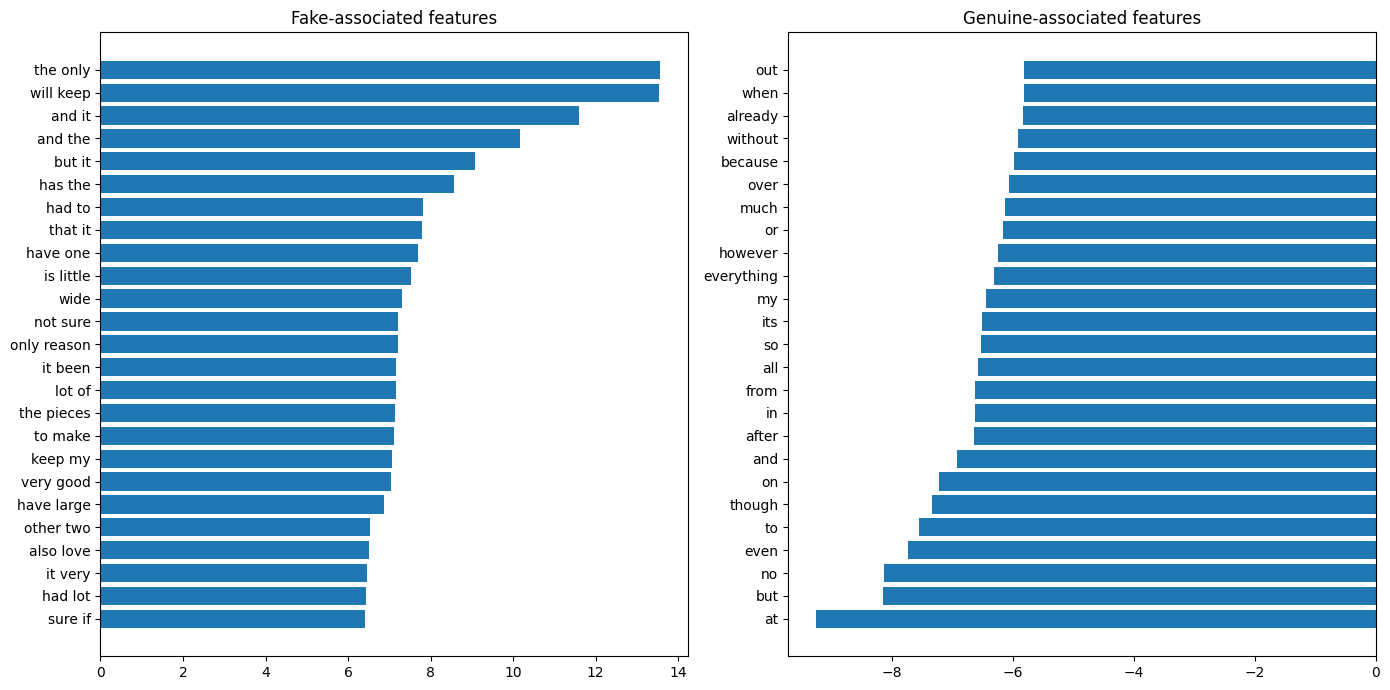

In [29]:
fig,ax=plt.subplots(1,2,figsize=(14,7))
ax[0].barh(fake_features.Feature[::-1],fake_features.Coefficient[::-1]); ax[0].set_title("Fake-associated features")
ax[1].barh(real_features.Feature,real_features.Coefficient); ax[1].set_title("Genuine-associated features")
plt.tight_layout(); plt.show()

In [30]:
errors = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": tuned_pred,
    "CG_probability": tuned_prob
})

errors = errors[errors.actual != errors.predicted].copy()

print("Misclassified reviews:", len(errors))
display(errors.sort_values("CG_probability").head(20))


Misclassified reviews: 406


,review,actual,predicted,CG_probability
1893,this was exactly what i was ordered for i did ...,1,0,0.003080
1873,good for tiny tots however i find it hard to p...,1,0,0.007711
1720,it s perfect covers my beach time perfectly an...,1,0,0.010388
6823,very cute bear but it doesn t really stand on ...,1,0,0.017577
6086,good gifts for a party great quality thanks fo...,1,0,0.018393
5127,there isn t much room in the back so you have ...,1,0,0.023593
2853,this play cube does not last very long the squ...,1,0,0.026168
2771,excellent product and a much better quality th...,1,0,0.026652
6681,read to your sons and daughters buy the book y...,1,0,0.028256
7739,great for adapting my 1 2 3 4 t threads to the 1,1,0,0.029090


In [31]:
final_model = grid.best_estimator_
final_vectorizer = tune_vectorizer

def predict_review(review):
    cleaned = clean_text(review)
    z = final_vectorizer.transform([cleaned])
    p = float(final_model.predict_proba(z)[0, 1])

    risk = "HIGH" if p >= .80 else ("MEDIUM" if p >= .50 else "LOW")

    return {
        "Prediction": "CG / SUSPICIOUS" if p >= .50 else "OR / ORIGINAL",
        "CG Probability": round(p, 4),
        "OR Probability": round(1 - p, 4),
        "Risk Level": risk
    }

examples = [
    "Absolutely amazing product!!! Best thing I have ever purchased. Buy it now!!!",
    "The product arrived two days late. The build quality is acceptable and the battery lasts around six hours."
]

for r in examples:
    print("\nReview:", r)
    print(predict_review(r))



Review: Absolutely amazing product!!! Best thing I have ever purchased. Buy it now!!!
{'Prediction': 'OR / ORIGINAL', 'CG Probability': 0.1384, 'OR Probability': 0.8616, 'Risk Level': 'LOW'}

Review: The product arrived two days late. The build quality is acceptable and the battery lasts around six hours.
{'Prediction': 'OR / ORIGINAL', 'CG Probability': 0.173, 'OR Probability': 0.827, 'Risk Level': 'LOW'}


In [32]:
# Optional live demo
try:
    user_review=input("Enter a product review: ")
    if user_review.strip(): print(predict_review(user_review))
except Exception: print("Interactive input unavailable.")

Enter a product review: Toys
{'Prediction': 'OR / ORIGINAL', 'CG Probability': 0.1476, 'OR Probability': 0.8524, 'Risk Level': 'LOW'}


In [34]:
MODEL_DIR="fake_review_model"; os.makedirs(MODEL_DIR,exist_ok=True)
joblib.dump(final_model,os.path.join(MODEL_DIR,"logistic_regression_model.joblib"))
joblib.dump(final_vectorizer,os.path.join(MODEL_DIR,"tfidf_vectorizer.joblib"))
print("Saved model and vectorizer in",MODEL_DIR)

Saved model and vectorizer in fake_review_model


In [35]:
loaded_model=joblib.load(os.path.join(MODEL_DIR,"logistic_regression_model.joblib"))
loaded_vectorizer=joblib.load(os.path.join(MODEL_DIR,"tfidf_vectorizer.joblib"))
def predict_saved(review):
    z=loaded_vectorizer.transform([clean_text(review)]); p=float(loaded_model.predict_proba(z)[0,1])
    return {"Prediction":"FAKE / SUSPICIOUS" if p>=.5 else "GENUINE","Fake Probability":round(p,4)}
print(predict_saved("The product works as described and arrived on time."))

{'Prediction': 'GENUINE', 'Fake Probability': 0.25}
